In [1]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import gc

from sklearn import metrics
import random
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

from sklearn.metrics import f1_score

def create_dir(path):
    if os.path.isdir(path)==False:
        os.makedirs(path)



In [2]:
# set the paths
testProbsPath='/gdrive/My Drive/Colab Notebooks/Landslide_class/testProbs/'
SUBMISSIONS_PATH='/gdrive/My Drive/Colab Notebooks/Landslide_class/submissions/'
oofPath='/gdrive/My Drive/Colab Notebooks/Landslide_class/OOF/'


In [3]:
name='Landslide_Class_S2S1_ensemble'

THRESH=0.5
USE_VERSIONS=['v18b', 'v10', 'v20', 'v31', 'v33', 'v37', 'v39', 'v44', 'v46']

In [4]:
# Define paths for the dataset (remember to unzip the dataset first!)
train_csv_path = 'Train.csv'  # Path to the training labels CSV file
test_csv_path = 'Test.csv'    # Path to the test image IDs CSV file
train_data_path = 'train_data/train_data'  # Folder where .npy train files are located
test_data_path = 'test_data/test_data'    # Folder where .npy test files are located

# Load Train.csv and inspect the data
train_df = pd.read_csv(train_csv_path)
print("Train.csv:")
print(train_df.head())

Train.csv:
          ID  label
0  ID_HUD1ST      1
1  ID_KGE2HY      1
2  ID_VHV9BL      1
3  ID_ZT0VEJ      0
4  ID_5NFXVY      0


In [5]:
train_df.label.value_counts()

,count
label,
0,5892
1,1255


In [6]:
# Load all training data to ram
folder_path=train_data_path+'/'
X = np.array([np.load(folder_path+image_id+'.npy') for image_id in train_df['ID']])
y = train_df['label'].values

# Load all test data to ram
test_df = pd.read_csv(test_csv_path)
test_ids = test_df['ID'].values
X_test = np.array([np.load(test_data_path+'/'+image_id+'.npy') for image_id in test_ids])

In [7]:
print(X.shape,X_test.shape)

(7147, 64, 64, 12) (5398, 64, 64, 12)


In [8]:
X.shape, y.shape

((7147, 64, 64, 12), (7147,))

In [9]:
X.max(),X.min()

(np.float64(20944.0), np.float64(-65.66225893514942))

In [10]:
v10=np.load(oofPath+'Landslide_Class_S2S1_v10.npz')['arr_0']
v10.shape

(7147,)

In [11]:
f1_score(y, (v10>THRESH).astype(int))

0.8744263662911973

In [12]:
allVs=[]
allTestVs=[]
oofDist={}
for i, f in enumerate(USE_VERSIONS):
    v=np.load(oofPath+'Landslide_Class_S2S1_'+f+'.npz')['arr_0'][:7147]
    allVs.append(v)
    oofDist[i]=f
    # allTestVs.append(np.load(testProbsPath+f)['arr_0'])
    print(i, f.split('_')[-1][:-4], f1_score(y, (v>THRESH).astype(int)))

0  0.8740801308258381
1  0.8744263662911973
2  0.8496362166531932
3  0.8976572133168927
4  0.8962993086620578
5  0.9003267973856209
6  0.8985858585858586
7  0.8708094848732625
8  0.8943747470659652


In [14]:
f1_score(y, (np.mean(np.stack(allVs),0)>THRESH).astype(int))

0.9216249487074272

In [16]:
def find_opt_thresh(targets, preds):
    bestthresh=0.5
    bestscore=-np.inf
    for i in range(98):
        thresh=0.01+i/100
        score= f1_score(targets, (preds>thresh).astype(int))
        if score>bestscore:
            bestscore=score
            bestthresh=thresh
    return round(bestthresh,2), bestscore
def plot_scoresPerThresh(OOF, fromT=40, toT=55):
    scores=[]
    for i in range(fromT,toT):
        score=f1_score(y, (OOF>i/100).astype(int))
        scores.append(score)
        # print(i/100,score)
    plt.plot(np.arange(40,55)/100,scores,'.-')
    plt.show()

OOF=    np.mean(np.stack(allVs),0)
bestthresh, bestscore=find_opt_thresh(y, OOF)
bestthresh, bestscore

(0.49, 0.9225727160999591)

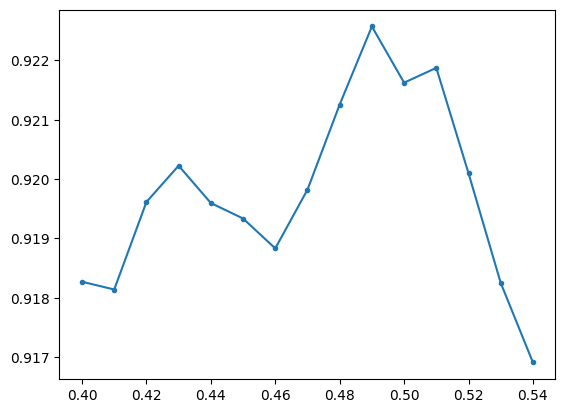

(0.9216249487074272, 0.49, 0.9225727160999591)

In [17]:
OOF=    np.mean(np.stack(allVs),0)
plot_scoresPerThresh(OOF)
f1_score(y, (OOF>THRESH).astype(int)),bestthresh, bestscore

In [18]:
# allVs=[]
allTestVs=[]

for key in range(9):
    f=oofDist[key]
    print(f)
    allTestVs.append(np.load(testProbsPath+'Landslide_Class_S2S1_'+f+'.npz')['arr_0'])
allTestVs=np.stack(allTestVs)
allTestVs.shape

v18b
v10
v20
v31
v33
v37
v39
v44
v46


(9, 5398)

In [19]:
for i in range(1,len(allTestVs)):
    print(np.corrcoef(allTestVs[0,:],allTestVs[i,:])[0,1])

0.8902968140991045
0.8957622702966237
0.905568888531242
0.9097624997265008
0.9112144066247668
0.9159942402413439
0.996423761412792
0.9130978997471887


In [20]:

test_preds01 = (np.mean(allTestVs,0)>0.49).astype(int)

# Count the number of predictions for each class
unique, counts = np.unique(test_preds01, return_counts=True)
prediction_counts = dict(zip(unique, counts))
print("Prediction counts:", prediction_counts)

# Prepare submission file
submission_df = pd.DataFrame({
    'ID': test_ids,
    'label': test_preds01.flatten()  # Flatten to match submission format
})
submission_df.to_csv(SUBMISSIONS_PATH+name+'AVGv101820313337394446_THRESH'+str(0.49)+'b.csv', index=False)


Prediction counts: {np.int64(0): np.int64(4782), np.int64(1): np.int64(616)}
